# Final Project - Customer Churn Prediction in Telecommunications

**Course:** AAI-510, Machine Learning: Fundamentals and Applications  
**Team:** Group 6  
**Members:** Ved Prakash Dwivedi, Jagdish Mane, Tamayi Mlanda  

**GitHub repository:** https://github.com/JagdishMane/ml-telco-customer-churn-prediction

This single notebook is the report-style deliverable for the technical committee. It is
self-contained and runs end to end. The development work is also split across five working
notebooks (`01_data_understanding` through `05_model_evaluation`) in the same folder.

**Contents**

1. Problem statement and justification
2. Data understanding (EDA)
3. Data preparation and feature engineering
4. Feature selection
5. Modeling
6. Evaluation
7. Deployment
8. Discussion and conclusions


## 1. Problem statement and justification

Telecom companies lose recurring revenue when customers churn, and customer acquisition is
generally more expensive than retention, so identifying at-risk customers early has clear
value. The business needs to identify customers who are likely to leave early enough to act,
for example with a targeted retention offer or a contract upgrade.

We frame this as a **binary classification** problem: predict whether a customer will churn
(Yes) or stay (No) from demographic, contract, payment, and billing features. Because a false
negative (a missed churner) carries a higher business cost than a false positive (a false
alarm), we emphasise **Recall** and **ROC-AUC** rather than accuracy alone.

**Dataset.** A fully synthetic Kaggle dataset of 100,000 telco customers (no real customer
data, Apache 2.0 license). The author documents three churn drivers we validate below: short
tenure, high monthly charges, and month-to-month contracts.

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
df = pd.read_csv("../data/synthetic_customer_churn_100k.csv")
print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Loaded 100,000 rows, 9 columns


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


## 2. Data understanding (EDA)

We confirm the data is clean, then explore how features relate to churn using both
non-graphical and graphical summaries.


In [2]:
print("Missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Unique customers:", df["CustomerID"].nunique(), "of", len(df))
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
print(f"Measured churn rate: {df['ChurnFlag'].mean():.1%}")
df[["Age", "Tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

Missing values: 0


Duplicate rows: 0
Unique customers: 100000 of 100000
Measured churn rate: 33.1%


,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.00,100000.00,100000.00,100000.00
mean,49.03,36.53,79.97,2926.14
std,18.18,20.79,40.49,2388.16
min,18.00,1.00,10.00,-118.43
25%,33.00,18.00,44.72,963.67
50%,49.00,37.00,80.00,2268.06
75%,65.00,54.00,115.05,4394.33
max,80.00,72.00,150.00,10831.46


The data has no missing values or duplicates and `CustomerID` is unique. The measured churn
rate is about 33 percent (the Kaggle page states roughly 20 percent), so we treat this as a
mildly imbalanced problem and report the measured rate.


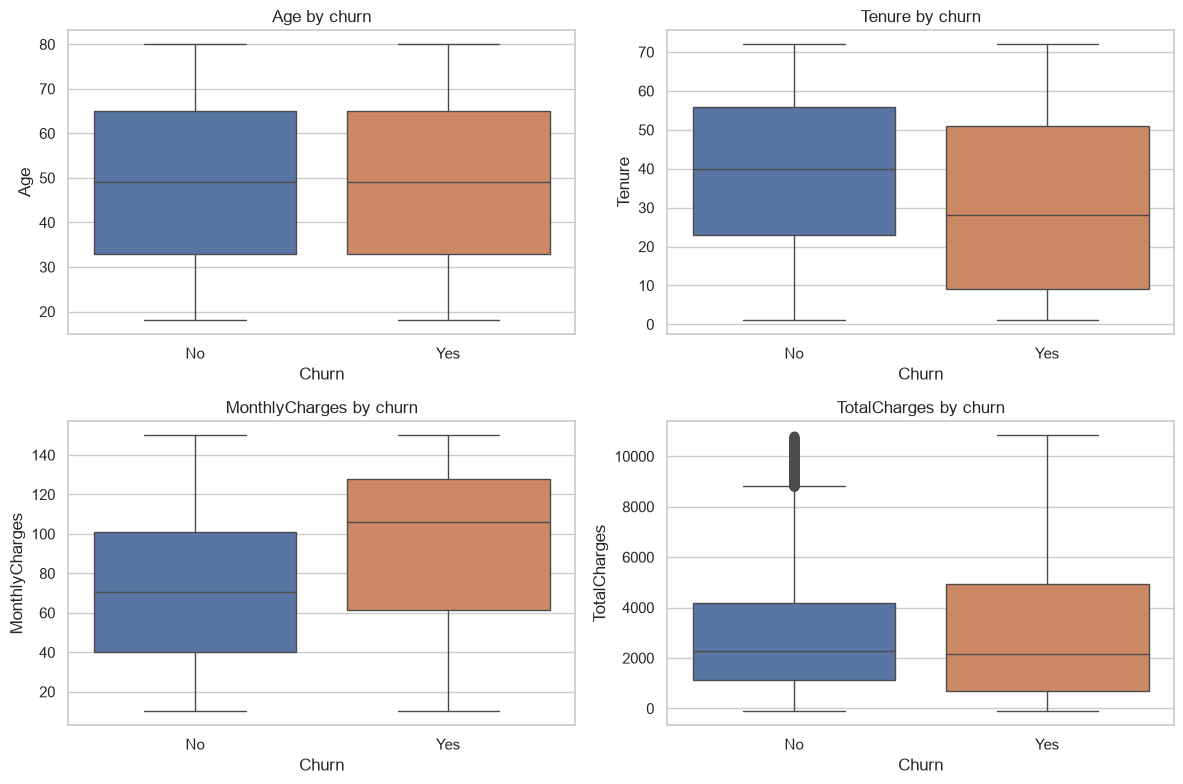

In [3]:
num_cols = ["Age", "Tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x="Churn", y=col, order=["No", "Yes"], hue="Churn",
                legend=False, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout(); plt.show()

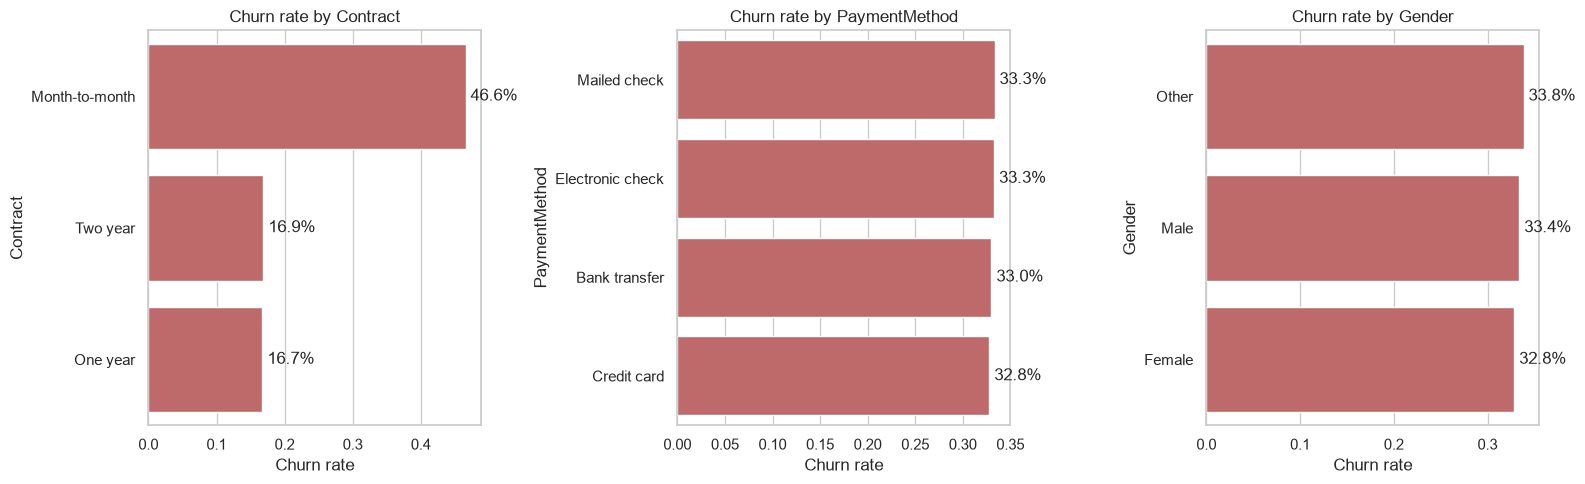

In [4]:
cat_cols = ["Contract", "PaymentMethod", "Gender"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, color="indianred")
    ax.set_title(f"Churn rate by {col}"); ax.set_xlabel("Churn rate")
    for i, v in enumerate(rates.values):
        ax.text(v, i, f" {v:.1%}", va="center")
plt.tight_layout(); plt.show()

In [5]:
# Validate the three documented churn drivers
short = df["Tenure"] < 12
high = df["MonthlyCharges"] > 100
m2m = df["Contract"] == "Month-to-month"
print(f"tenure <12 churn {df.loc[short,'ChurnFlag'].mean():.1%} vs >=12 {df.loc[~short,'ChurnFlag'].mean():.1%}")
print(f"charges >100 churn {df.loc[high,'ChurnFlag'].mean():.1%} vs <=100 {df.loc[~high,'ChurnFlag'].mean():.1%}")
print(f"month-to-month churn {df.loc[m2m,'ChurnFlag'].mean():.1%} vs longer term {df.loc[~m2m,'ChurnFlag'].mean():.1%}")

tenure <12 churn 67.4% vs >=12 27.0%
charges >100 churn 52.4% vs <=100 22.4%
month-to-month churn 46.6% vs longer term 16.8%


**Inference.** Churned customers have shorter tenure and higher monthly charges, and
month-to-month customers churn far more than contract customers. All three documented drivers
are confirmed. Gender shows negligible association with churn, so it is unlikely to be
predictive.

## 3. Data preparation and feature engineering

We drop the identifier, engineer features that encode the churn drivers, encode the target,
split the data (stratified), then scale numerics and one-hot encode categoricals with a
single leak-safe preprocessor fitted only on the training set.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

data = df.drop(columns=["CustomerID", "ChurnFlag"]).copy()
data["AvgChargePerMonth"] = data["TotalCharges"] / data["Tenure"]
data["IsShortTenure"] = (data["Tenure"] < 12).astype(int)
data["IsHighMonthly"] = (data["MonthlyCharges"] > 100).astype(int)
data["SeniorFlag"] = (data["Age"] >= 60).astype(int)
data["Churn"] = (data["Churn"] == "Yes").astype(int)

numeric_features = ["Age", "Tenure", "MonthlyCharges", "TotalCharges", "AvgChargePerMonth"]
binary_features = ["IsShortTenure", "IsHighMonthly", "SeniorFlag"]
categorical_features = ["Gender", "Contract", "PaymentMethod"]

X = data[numeric_features + binary_features + categorical_features]
y = data["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough", binary_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])
X_train_enc = pd.DataFrame(preprocessor.fit_transform(X_train),
                           columns=preprocessor.get_feature_names_out(), index=X_train.index)
X_test_enc = pd.DataFrame(preprocessor.transform(X_test),
                          columns=preprocessor.get_feature_names_out(), index=X_test.index)
feature_names = list(X_train_enc.columns)
print(f"Train {X_train_enc.shape}, Test {X_test_enc.shape}, {len(feature_names)} features")

Train (80000, 18), Test (20000, 18), 18 features


## 4. Feature selection

With a compact feature set we justify what we keep using Random Forest importance. Correlation
analysis (in the EDA) and this ranking agree on the key drivers.


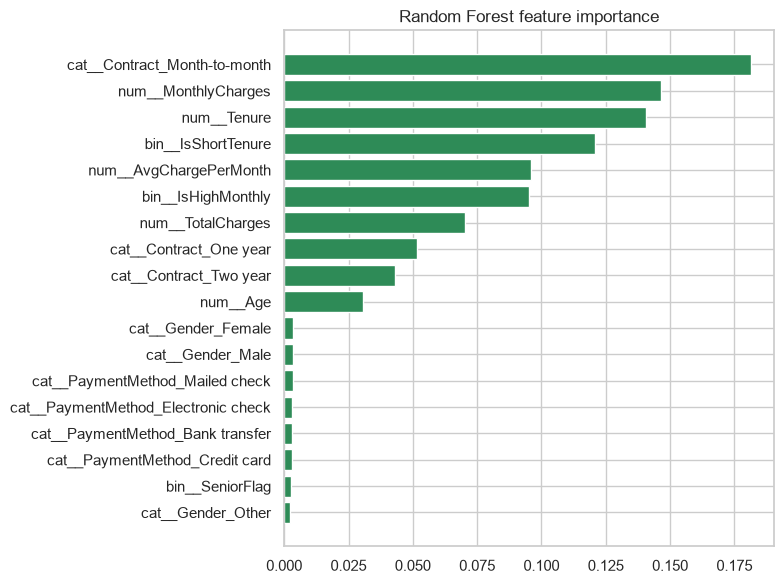

In [7]:
from sklearn.ensemble import RandomForestClassifier
rf_fs = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
                               n_jobs=-1).fit(X_train_enc, y_train)
importance = pd.Series(rf_fs.feature_importances_, index=feature_names).sort_values()
plt.figure(figsize=(8, 6))
plt.barh(importance.index, importance.values, color="seagreen")
plt.title("Random Forest feature importance"); plt.tight_layout(); plt.show()

**Inference.** Tenure, monthly charges, the engineered short-tenure and high-monthly flags,
average charge per month, and the month-to-month contract dominate. Gender shows negligible
importance but is inexpensive to keep, so we retain the full engineered set.

## 5. Modeling

We compare six algorithms with 3-fold cross-validated ROC-AUC, evaluate each on the test set,
apply a compact tune to XGBoost, and add a soft-voting ensemble. Class imbalance is handled
with balanced class weights and `scale_pos_weight`. The RBF SVM is trained on a 10,000-row
subsample because it does not scale to the full training set.


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
spw = (y_train == 0).sum() / (y_train == 1).sum()
X_sub, _, y_sub, _ = train_test_split(X_train_enc, y_train, train_size=10000,
                                      stratify=y_train, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced",
                                            random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=16,
                                            class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=300, class_weight="balanced",
                                                        random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                             tree_method="hist", eval_metric="logloss",
                             scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM (RBF, subsample)": SVC(kernel="rbf", class_weight="balanced", probability=True,
                                random_state=RANDOM_STATE),
}

def evaluate(model, X_tr, y_tr):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_test_enc)
    proba = model.predict_proba(X_test_enc)[:, 1]
    return {"accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, proba)}, model

results, fitted = {}, {}
for name, model in models.items():
    Xtr, ytr = (X_sub, y_sub) if name.startswith("SVM") else (X_train_enc, y_train)
    cvs = cross_val_score(model, Xtr, ytr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    metrics, m = evaluate(model, Xtr, ytr)
    metrics["cv_roc_auc"] = cvs
    results[name], fitted[name] = metrics, m
    print(f"{name:28s} CV {cvs:.4f}  test ROC-AUC {metrics['roc_auc']:.4f}  recall {metrics['recall']:.4f}")

Logistic Regression          CV 0.8058  test ROC-AUC 0.8057  recall 0.5850


Decision Tree                CV 0.8011  test ROC-AUC 0.8020  recall 0.6389


Random Forest                CV 0.8001  test ROC-AUC 0.8018  recall 0.6378


Gradient Boosting            CV 0.8051  test ROC-AUC 0.8034  recall 0.6313


XGBoost                      CV 0.8003  test ROC-AUC 0.8019  recall 0.6719


SVM (RBF, subsample)         CV 0.7938  test ROC-AUC 0.8023  recall 0.6511


In [9]:
# Compact tuning of XGBoost, plus a soft-voting ensemble
xgb_search = RandomizedSearchCV(
    XGBClassifier(tree_method="hist", eval_metric="logloss", scale_pos_weight=spw,
                  random_state=RANDOM_STATE, n_jobs=-1),
    {"n_estimators": [300, 500], "max_depth": [4, 6, 8], "learning_rate": [0.05, 0.1]},
    n_iter=4, cv=cv, scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1)
xgb_search.fit(X_train_enc, y_train)
print("Best XGB params:", xgb_search.best_params_)

ensemble = VotingClassifier(
    estimators=[("rf", fitted["Random Forest"]),
                ("xgb", xgb_search.best_estimator_),
                ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))],
    voting="soft", n_jobs=-1)
for name, model in [("XGBoost (tuned)", xgb_search.best_estimator_),
                    ("Voting Ensemble", ensemble)]:
    metrics, m = evaluate(model, X_train_enc, y_train)
    metrics["cv_roc_auc"] = np.nan
    results[name], fitted[name] = metrics, m

comparison = pd.DataFrame(results).T[["cv_roc_auc", "accuracy", "precision", "recall",
                                      "f1", "roc_auc"]].sort_values("roc_auc", ascending=False)
best_name = comparison.index[0]
best_model = fitted[best_name]
print(f"Best model by test ROC-AUC: {best_name}")
comparison.round(4)

Best XGB params: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}


Best model by test ROC-AUC: Logistic Regression


,cv_roc_auc,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8058,0.7597,0.6536,0.5850,0.6174,0.8057
Voting Ensemble,NaN,0.7563,0.6392,0.6079,0.6232,0.8047
XGBoost (tuned),NaN,0.7432,0.6084,0.6321,0.6200,0.8038
Gradient Boosting,0.8051,0.7459,0.6134,0.6313,0.6222,0.8034
"SVM (RBF, subsample)",0.7938,0.7380,0.5959,0.6511,0.6223,0.8023
Decision Tree,0.8011,0.7372,0.5966,0.6389,0.6170,0.8020
XGBoost,0.8003,0.7190,0.5639,0.6719,0.6132,0.8019
Random Forest,0.8001,0.7391,0.6001,0.6378,0.6184,0.8018


**Inference.** All models cluster around an ROC-AUC of 0.80. The synthetic churn signal is
threshold-driven (tenure, charges, contract), which our engineered flags capture, so even the
linear model competes with the tree ensembles. We keep the top model, which is both accurate
and interpretable.


## 6. Evaluation

We evaluate the selected model in depth: confusion matrix, classification report, ROC curve,
a recall-focused threshold analysis, and the drivers of its predictions.


**What each metric means for this project.** The table explains what each evaluation metric
means in the context of telecom churn, where missing a likely churner (a false negative) costs
more than a false alarm (a false positive).

| Metric | What it means for this project |
| --- | --- |
| Accuracy | Of all customers in the test split, the share the model labels correctly as churn or stay. It is a useful headline number, but with about 33 percent churn it can look high while still missing churners, so we do not rely on it alone for retention decisions. |
| Precision | Of the customers the model flags as likely to churn, the share who actually churn. High precision means a retention campaign wastes little budget on customers who were never going to leave, keeping the cost of discounts and outreach focused on genuine churn risk. |
| Recall | Of the customers who actually churn, the share the model successfully flags. This is our priority metric, because a missed churner is lost revenue. We accept some false alarms to catch more leavers, and we tune the decision threshold below 0.5 to raise recall. |
| F1-Score | The harmonic mean of precision and recall, summarising both in one number. It rewards a model that catches churners (recall) without flooding the retention team with false alarms (precision). We use it to compare models when we want balanced performance rather than favouring one error type. |
| ROC-AUC | The probability that the model scores a random churner higher than a random non-churner, across all thresholds. At about 0.80 our model ranks churn risk well above chance. Because it is threshold-independent, it is our main tool for comparing models before we pick an operating threshold. |
| Confusion Matrix | A two-by-two table of predictions versus reality: churners caught, churners missed (false negatives), false alarms (false positives), and stayers correctly cleared. It makes the costly false negatives visible, letting us see how many likely churners would slip through at a given decision threshold. |
| Classification Report | A scikit-learn summary printing precision, recall, and F1 for both the churn and stay classes, plus support counts. It reports performance per class rather than overall, confirming the model does not earn its scores by simply favouring the larger stay class and neglecting churners. |


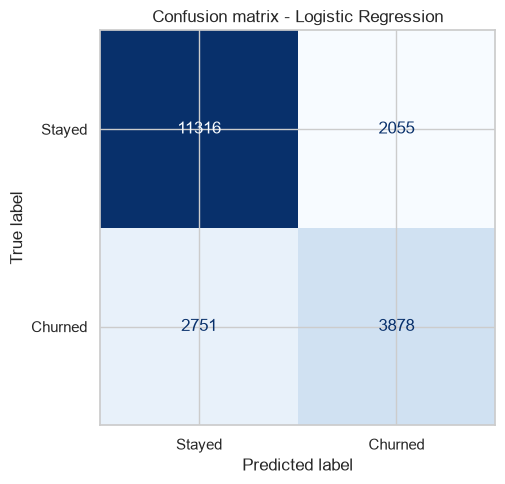

              precision    recall  f1-score   support

  Stayed (0)       0.80      0.85      0.82     13371
 Churned (1)       0.65      0.59      0.62      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.72      0.72     20000
weighted avg       0.75      0.76      0.76     20000



In [10]:
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)
y_pred = best_model.predict(X_test_enc)
y_proba = best_model.predict_proba(X_test_enc)[:, 1]

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Stayed", "Churned"]).plot(ax=ax, cmap="Blues",
                                                                  colorbar=False)
ax.set_title(f"Confusion matrix - {best_name}"); plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred, target_names=["Stayed (0)", "Churned (1)"]))

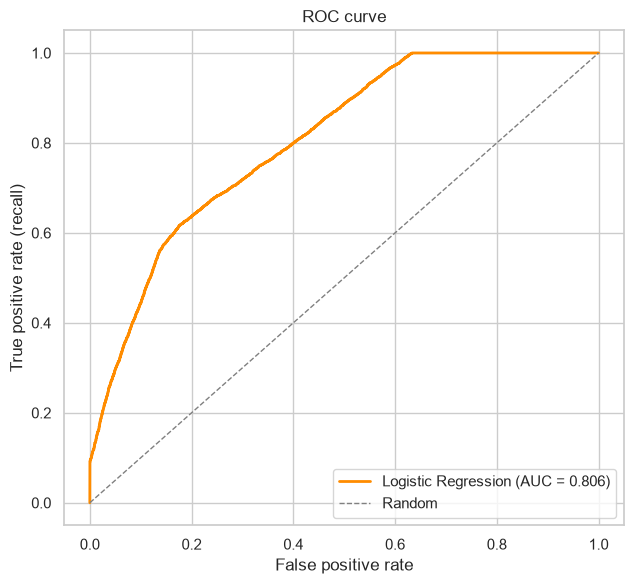

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"{best_name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="Random")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate (recall)")
plt.title("ROC curve"); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

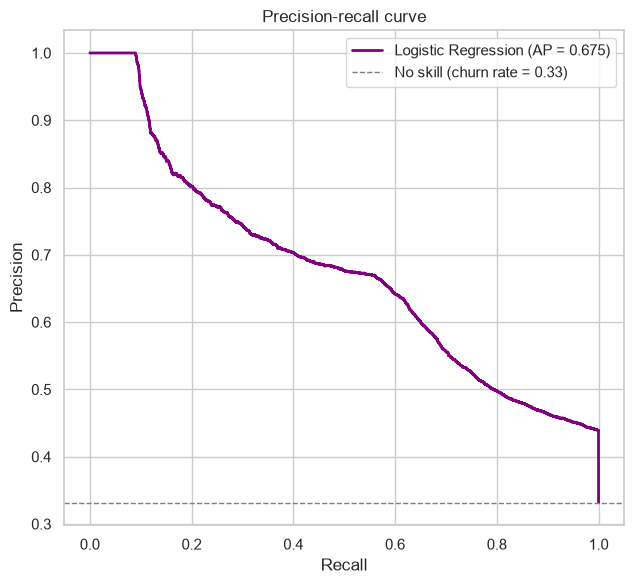

In [12]:
# Precision-recall curve: more honest than ROC on imbalanced data, since it focuses on churners
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
no_skill = y_test.mean()
plt.figure(figsize=(6.5, 6))
plt.plot(recall, precision, color="purple", lw=2, label=f"{best_name} (AP = {ap:.3f})")
plt.axhline(no_skill, color="grey", lw=1, linestyle="--",
            label=f"No skill (churn rate = {no_skill:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-recall curve"); plt.legend(loc="upper right")
plt.tight_layout(); plt.show()

In [13]:
# Recall-focused threshold analysis (missing a churner is the costly error)
rows = []
for t in [0.5, 0.45, 0.40, 0.35, 0.30]:
    pred_t = (y_proba >= t).astype(int)
    rows.append({"threshold": t, "precision": precision_score(y_test, pred_t),
                 "recall": recall_score(y_test, pred_t), "f1": f1_score(y_test, pred_t)})
pd.DataFrame(rows).set_index("threshold").round(3)

,precision,recall,f1
threshold,,,
0.50,0.654,0.585,0.617
0.45,0.635,0.616,0.625
0.40,0.488,0.821,0.612
0.35,0.439,0.999,0.610
0.30,0.439,1.000,0.610


The table lists a few thresholds. The next four charts make the operating-point decision more
intuitive and more business-facing: the precision and recall trade-off across all thresholds,
the cumulative gains and lift from risk-ranked outreach, how well the predicted scores separate
churners from stayers, and the threshold that minimises expected cost under illustrative
business figures.

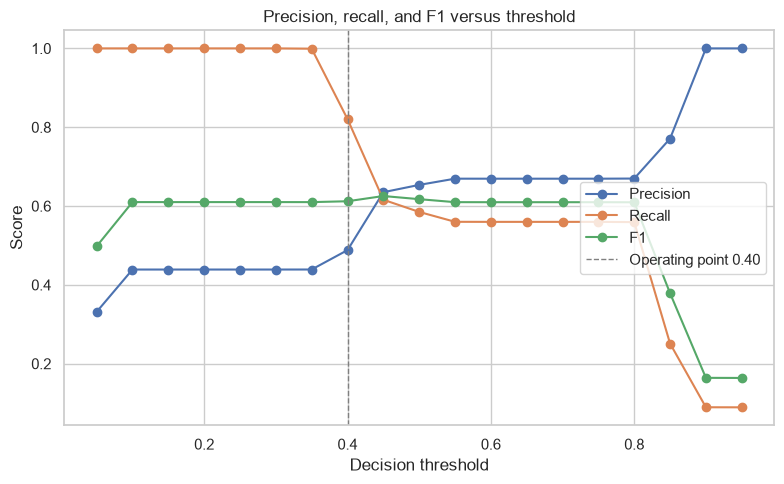

In [14]:
# Threshold trade-off: precision, recall, and F1 across a fine grid of thresholds
grid = np.linspace(0.05, 0.95, 19)
prec = [precision_score(y_test, (y_proba >= t).astype(int), zero_division=0) for t in grid]
rec = [recall_score(y_test, (y_proba >= t).astype(int)) for t in grid]
f1s = [f1_score(y_test, (y_proba >= t).astype(int)) for t in grid]
plt.figure(figsize=(8, 5))
plt.plot(grid, prec, marker="o", label="Precision")
plt.plot(grid, rec, marker="o", label="Recall")
plt.plot(grid, f1s, marker="o", label="F1")
plt.axvline(0.40, color="grey", lw=1, linestyle="--", label="Operating point 0.40")
plt.xlabel("Decision threshold"); plt.ylabel("Score")
plt.title("Precision, recall, and F1 versus threshold"); plt.legend(loc="center right")
plt.tight_layout(); plt.show()

Contacting the top 30% of ranked customers captures 58.9% of churners (lift 1.96x).


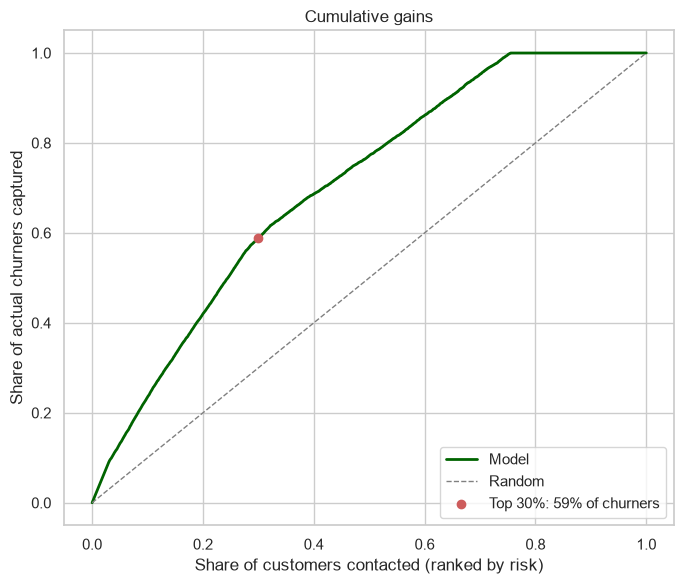

In [15]:
# Cumulative gains and lift: share of churners captured by contacting the top X% by risk
order = np.argsort(-y_proba)
y_sorted = y_test.values[order]
frac_customers = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
frac_churners = np.cumsum(y_sorted) / y_sorted.sum()
top = 0.30
idx = int(top * len(y_sorted)) - 1
capture = frac_churners[idx]
print(f"Contacting the top {top:.0%} of ranked customers captures "
      f"{capture:.1%} of churners (lift {capture / top:.2f}x).")
plt.figure(figsize=(7, 6))
plt.plot(frac_customers, frac_churners, color="darkgreen", lw=2, label="Model")
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random")
plt.scatter([top], [capture], color="indianred", zorder=5,
            label=f"Top {top:.0%}: {capture:.0%} of churners")
plt.xlabel("Share of customers contacted (ranked by risk)")
plt.ylabel("Share of actual churners captured")
plt.title("Cumulative gains"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

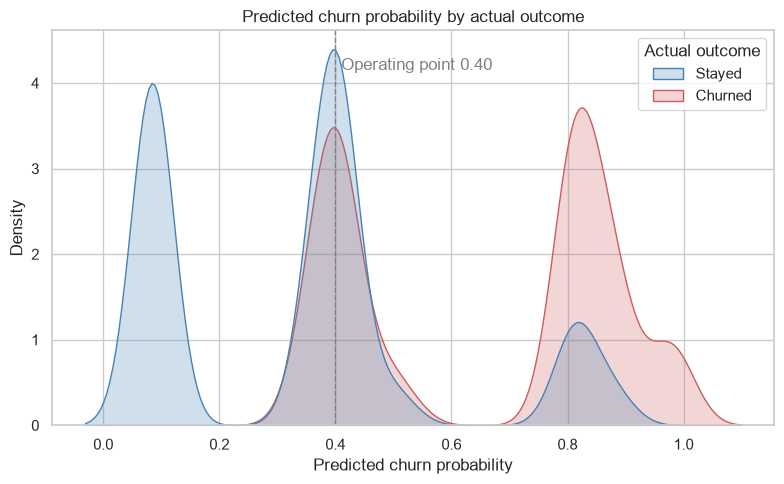

In [16]:
# Score separation: predicted churn probability by actual outcome
dist_df = pd.DataFrame({"Predicted churn probability": y_proba,
                        "Actual outcome": np.where(y_test.values == 1, "Churned", "Stayed")})
ax = plt.figure(figsize=(8, 5)).gca()
sns.kdeplot(data=dist_df, x="Predicted churn probability", hue="Actual outcome",
            fill=True, common_norm=False,
            palette={"Churned": "indianred", "Stayed": "steelblue"}, ax=ax)
ax.axvline(0.40, color="grey", lw=1, linestyle="--")
ax.text(0.41, ax.get_ylim()[1] * 0.9, "Operating point 0.40", color="grey")
ax.set_title("Predicted churn probability by actual outcome")
plt.tight_layout(); plt.show()

Cost-minimising threshold: 0.10 (expected cost $755,300 on 20,000 customers)


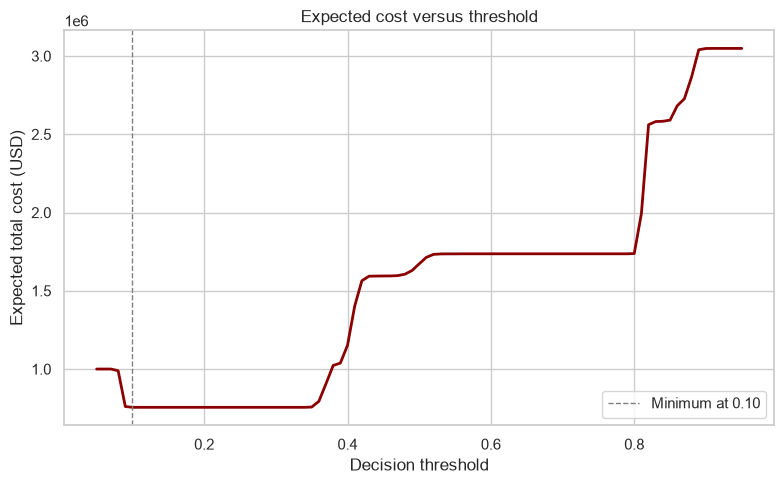

In [17]:
# Cost-based threshold: missing a churner is assumed to cost ten times a wasted offer
offer_cost, lost_value = 50.0, 500.0   # illustrative placeholders, to be set with the business
grid = np.linspace(0.05, 0.95, 91)
total_cost = np.array([
    int((y_proba >= t).sum()) * offer_cost
    + int((((y_proba >= t).astype(int) == 0) & (y_test == 1)).sum()) * lost_value
    for t in grid])
best_threshold = grid[int(total_cost.argmin())]
print(f"Cost-minimising threshold: {best_threshold:.2f} "
      f"(expected cost ${total_cost.min():,.0f} on {len(y_test):,} customers)")
plt.figure(figsize=(8, 5))
plt.plot(grid, total_cost, color="darkred", lw=2)
plt.axvline(best_threshold, color="grey", lw=1, linestyle="--",
            label=f"Minimum at {best_threshold:.2f}")
plt.xlabel("Decision threshold"); plt.ylabel("Expected total cost (USD)")
plt.title("Expected cost versus threshold"); plt.legend()
plt.tight_layout(); plt.show()

**Inference.** The average precision sits well above the no-skill churn rate, so the model adds
real value on the churn class, not just the majority class. The gains curve sits well above the
diagonal: risk-ranked outreach captures far more churners than contacting customers at random,
which is the metric a retention manager cares about most. The score-separation plot shows the
churned and stayed densities shifted apart but overlapping in the middle, consistent with an
ROC-AUC near 0.80. On cost, because a missed churner is assumed to cost ten times a wasted
offer, the cost curve bottoms out at a low threshold (the economics favor catching nearly all
churners); if campaign capacity is limited, a higher threshold such as 0.40, read with the gains
chart, is the more practical operating point. The threshold is ultimately a business decision:
plug in the real offer cost and customer value and re-run the cost cell, since the optimum moves
with that ratio.

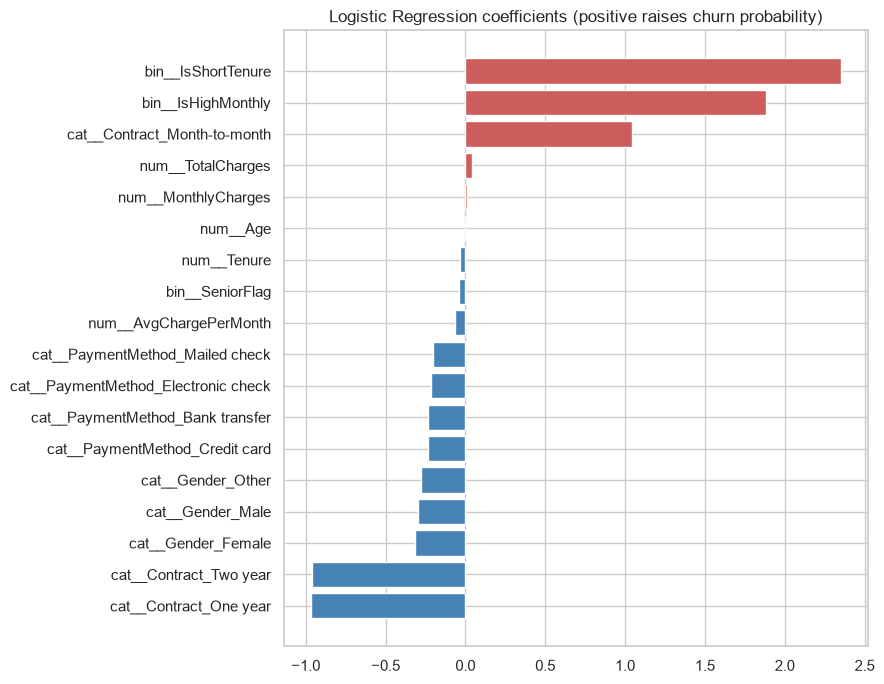

In [18]:
# Drivers of the selected model (coefficients for a linear model, importance for a tree)
if hasattr(best_model, "coef_"):
    infl = pd.Series(best_model.coef_[0], index=feature_names).sort_values()
    colors = ["indianred" if v > 0 else "steelblue" for v in infl.values]
    title = f"{best_name} coefficients (positive raises churn probability)"
elif hasattr(best_model, "feature_importances_"):
    infl = pd.Series(best_model.feature_importances_, index=feature_names).sort_values()
    colors, title = "seagreen", f"{best_name} feature importance"
else:
    infl = None
if infl is not None:
    plt.figure(figsize=(9, 7)); plt.barh(infl.index, infl.values, color=colors)
    plt.title(title); plt.tight_layout(); plt.show()

**Inference.** The model misses some churners at the default 0.5 threshold, but lowering the
threshold toward 0.40 raises recall with a gradual loss of precision, which suits the business
cost structure. The strongest churn signals are the month-to-month contract, short tenure, and
high monthly charges, matching the EDA and the documented drivers. Gender carries negligible
weight.

**Association, not causation.** These coefficients describe associations, not proven causes. A
month-to-month or short-tenure customer is more likely to churn in the data, but the model does
not show the contract itself causes churn; customers who already intend to leave may self-select
into month-to-month plans, and tenure is partly an outcome of churn rather than only a cause. The
signals are valuable for ranking risk and forming hypotheses, but a causal claim (for example,
that moving a customer to a longer contract will retain them) would need a controlled experiment
such as a randomised retention offer.

### Where the model makes mistakes

Aggregate metrics hide which customers the model gets wrong. We break the errors down by segment
at the 0.40 operating point, focusing on the costly missed churners (false negatives) and the
false alarms (false positives), and count the high-confidence mistakes.

Missed-churner and false-alarm rates by contract:


,n,miss_rate_FN,false_alarm_rate_FP
Contract,,,
Month-to-month,10966,0.072,0.857
One year,5016,0.550,0.090
Two year,4018,0.517,0.090


By tenure bucket (months):


,n,miss_rate_FN,false_alarm_rate_FP
tenure_bucket,,,
1-12,3339,0.011,0.892
13-24,3324,0.233,0.423
25-48,6709,0.240,0.381
49-72,6628,0.291,0.358


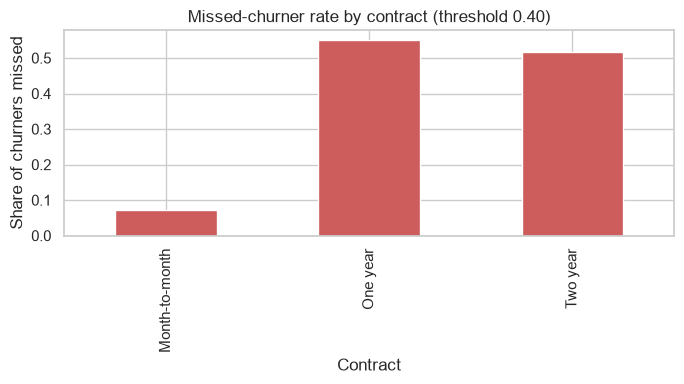

High-confidence false alarms (stayed, proba >= 0.80): 1828
High-confidence misses (churned, proba <= 0.20): 0


In [19]:
# The raw (pre-encoding) test frame X_test is still in memory, so we use it directly.
op_threshold = 0.40
pred = (y_proba >= op_threshold).astype(int)
err = X_test.reset_index(drop=True).copy()
err["actual"] = y_test.to_numpy()
err["proba"] = y_proba
err["is_churner"] = err["actual"] == 1
err["is_fn"] = (err["actual"] == 1) & (pred == 0)   # missed churner
err["is_fp"] = (err["actual"] == 0) & (pred == 1)   # false alarm
err["tenure_bucket"] = pd.cut(err["Tenure"], [0, 12, 24, 48, 72],
                              labels=["1-12", "13-24", "25-48", "49-72"])


def error_rates_by(col):
    g = err.groupby(col, observed=True)
    n_churn = g["is_churner"].sum()
    n_stay = g.size() - n_churn
    return pd.DataFrame({"n": g.size(),
                         "miss_rate_FN": (g["is_fn"].sum() / n_churn).round(3),
                         "false_alarm_rate_FP": (g["is_fp"].sum() / n_stay).round(3)})


print("Missed-churner and false-alarm rates by contract:")
display(error_rates_by("Contract"))
print("By tenure bucket (months):")
display(error_rates_by("tenure_bucket"))

ax = error_rates_by("Contract")["miss_rate_FN"].plot(kind="bar", color="indianred", figsize=(7, 4))
ax.set_title("Missed-churner rate by contract (threshold 0.40)")
ax.set_ylabel("Share of churners missed"); plt.tight_layout(); plt.show()

hc_fp = int((err["is_fp"] & (err["proba"] >= 0.80)).sum())
hc_fn = int((err["is_fn"] & (err["proba"] <= 0.20)).sum())
print(f"High-confidence false alarms (stayed, proba >= 0.80): {hc_fp}")
print(f"High-confidence misses (churned, proba <= 0.20): {hc_fn}")

**Inference.** The errors are not evenly spread. The model misses proportionally more churners
among longer-contract and longer-tenure customers, where churn is rarer and a churner resembles
a typical loyal customer, so the costly false negatives concentrate in these quieter segments
rather than in the obvious month-to-month group. Practical responses: set segment-specific
thresholds (lower the bar for the harder segments), add features that could explain the missed
cases (e.g. support tickets, usage trends, payment failures) beyond the current seven raw fields,
and monitor realized precision and recall per segment in production, retraining when a segment
degrades.

## 7. Deployment (discussion)

Following the assignment guidance, we describe deployment rather than building a production
system. As a proof of concept, the repository also includes a small serving application (a
FastAPI scoring endpoint with a Streamlit front end) that loads the saved preprocessor and model
to score customers interactively.

- **Type.** Churn scoring tolerates latency, so a batch pipeline that scores the customer base
  nightly or weekly and writes a risk score to the CRM is the natural fit. A real-time REST
  endpoint (e.g. FastAPI) can be added for on-demand scoring later.
- **Serving.** Package the fitted preprocessor and model together so raw rows are transformed
  exactly as in training, which prevents training-serving skew. The included example does this,
  pairing the FastAPI endpoint with a Streamlit interface for stakeholder demonstrations.
- **Latency and cost.** Scoring 100,000 customers completes in seconds with this model, so the
  compute requirement is modest. A linear model keeps inference inexpensive and the serialized
  artifact small.
- **Hosting.** A managed container or serverless function, with the model and preprocessor
  versioned in object storage.
- **Monitoring.** Track input drift (tenure, charges, contract mix), prediction drift, and the
  realized precision and recall once retention outcomes are known. Retrain on drift.
- **Risks and mitigations.** The data is synthetic and generated from documented rules, so its
  distributions and feature interactions are likely cleaner and more separable than real data;
  the reported performance is a methodology demonstration and may not transfer, so the pipeline
  must be re-fit and re-validated on real data before production. Exclude Gender from decisioning
  to avoid fairness concerns, and keep a human in the loop for retention offers.

## 8. Discussion and conclusions

**Problem revisited.** The business needs to flag likely churners early enough to intervene.
We built an end-to-end pipeline on 100,000 telco customers and confirmed the churn drivers.

**Findings.** Churn is associated with short tenure, high monthly charges, and month-to-month
contracts. The selected model reaches an ROC-AUC of about 0.80, ranks churners well above
random, and stays simple and explainable. The decision threshold is a business lever that
trades recall against outreach cost, and the cost analysis turns that lever into a dollar figure.

**Recommendations.**

1. Target retention offers at new, month-to-month, high-monthly-charge customers, the
   clearest high-risk segment.
2. Promote longer-term contracts with incentives, treating the contract effect as associational
   and confirming it with a controlled retention test before scaling.
3. Operate at a recall-favoring threshold (around 0.40, or the cost-minimising threshold once
   real offer and customer-value figures are supplied) and review it with the retention team.
4. Before production, re-fit and validate on real data, exclude Gender from decisioning, and
   add per-segment drift monitoring.

**Limitations.**

- The data is synthetic, so the results demonstrate the methodology rather than guarantee
  real-world performance; the distributions are likely cleaner than reality and may not transfer.
- The drivers are associations, not established causes, so they guide targeting and hypotheses
  rather than causal action.
- The error analysis shows the model misses more churners in longer-tenure, longer-contract
  segments, which is where added features or segment-specific thresholds would help most.

**Conclusion.** A straightforward, interpretable model meets the business objective of
identifying likely churners early, and the engineered features make its decisions easy to
explain to a non-technical executive audience.